# Knowledge Distillation
- The concept of **knowledge distillation** is to utilize class probabilities of a higher-capacity model (teacher) as soft targets of a smaller model (student)
- The implement processes can be divided into several stages:
  1. Finish the `ResNet()` classes
  2. Train the teacher model (ResNet50) and the student model (ResNet18) from scratch, i.e. **without KD**
  3. Define the `Distiller()` class and `loss_re()`, `loss_fe()` functions
  4. Train the student model **with KD** from the teacher model in two different ways, response-based and feature based distillation
  5. Comparison of student models w/ & w/o KD

## Setup

In [1]:
! pip install torchinfo

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, random_split
from torchinfo import summary
from tqdm import tqdm
import sys
import numpy as np
import math
import matplotlib.pyplot as plt
import os
from PIL import Image

In [3]:
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

## Download dataset

In [4]:
validation_split = 0.2
batch_size = 128

# data augmentation and normalization
transform_train = transforms.Compose([
                    transforms.RandomCrop(32, padding=4),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])

transform_test = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# download dataset
train_and_val_dataset = torchvision.datasets.CIFAR10(
    root='dataset/',
    train=True,
    transform=transform_train,
    download=True
)

test_dataset = torchvision.datasets.CIFAR10(
    root='dataset/',
    train=False,
    transform=transform_test,
    download=True
)

# split train and validation dataset
train_size = int((1 - validation_split) * len(train_and_val_dataset))
val_size = len(train_and_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_and_val_dataset, [train_size, val_size])

# create dataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

test_num = len(test_dataset)
test_steps = len(test_loader)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


## Create teacher and student models
### Define BottleNeck for ResNet50

In [5]:
class BottleNeck(nn.Module):
    expansion = 4

    def __init__(self, in_channel, out_channel, stride=1, downsample=None, **kwargs):
        super(BottleNeck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels=out_channel, kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.conv2 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channel)
        self.conv3 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel * self.expansion, kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channel * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity
        out = self.relu(out)

        return out

### Define Resifual Block

In [6]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channel, out_channel, stride=1, downsample=None, **kwargs):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels=out_channel, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channel)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

### Define ResNet Model

In [7]:
class ResNet(nn.Module):

    def __init__(self, block, blocks_num, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channel = 64

        self.conv1 = nn.Conv2d(3, self.in_channel, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channel)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, blocks_num[0])
        self.layer2 = self._make_layer(block, 128, blocks_num[1], stride=2)
        self.layer3 = self._make_layer(block, 256, blocks_num[2], stride=2)
        self.layer4 = self._make_layer(block, 512, blocks_num[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def _make_layer(self, block, channel, block_num, stride=1):
        downsample = None
        if stride != 1 or self.in_channel != channel * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channel, channel * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(channel * block.expansion))

        layers = []
        layers.append(block(self.in_channel, channel, downsample=downsample, stride=stride))
        self.in_channel = channel * block.expansion

        for _ in range(1, block_num):
            layers.append(block(self.in_channel, channel))

        return nn.Sequential(*layers)

    def forward(self, x):
        # 1. Finish the forward pass and return the output layer as well as hidden features.
        # 2. The output layer and hidden features will be used later for distilling.
        # 3. You can refer to the ResNet structure illustration to finish it.
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers, capturing hidden features
        feature1 = self.layer1(x)
        feature2 = self.layer2(feature1)
        feature3 = self.layer3(feature2)
        feature4 = self.layer4(feature3)

        # Final layers for output
        x = self.avgpool(feature4)
        x = x.view(x.size(0), -1)
        output = self.fc(x)

        # Return output and hidden features for distillation
        return x, [feature1, feature2, feature3, feature4]

### Define ResNet50 and Resnet18

In [8]:
def resnet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)

def resnet50(num_classes=10):
    return ResNet(BottleNeck, [3, 4, 6, 3], num_classes=num_classes)

## Teacher Model (ResNet50)

In [9]:
Teacher = resnet50(num_classes=10)  # commment out this line if loading trained teacher model
# Teacher = torch.load('Teacher.pt', weights_only=False)  # loading trained teacher model
Teacher = Teacher.to(device)

In [10]:
summary(Teacher)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            1,728
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BottleNeck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─BottleNeck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

## Student Model (ResNet18)

In [11]:
Student = resnet18(num_classes=10)  # commment out this line if loading trained student model
# Student = torch.load('Student.pt', weights_only=False)  # loading trained student model
Student = Student.to(device)

In [12]:
summary(Student)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            1,728
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─BasicBlock: 2-1                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    └─BasicBlock: 2-2                   --
│    │    └─Conv2d: 3-6                  36,864
│    │    └─BatchNorm2d: 3-7             128
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  36,864
│    │    └─BatchNorm2d: 3-10            128
├─Sequential: 1-6                        --
│    └─BasicBlock: 2-3                   --
│    │    └─Conv2d: 3-11                 73,728

## Define training function

In [13]:
def train_from_scratch(model, train_loader, val_loader, epochs, learning_rate, device, model_name):
    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=learning_rate)

    loss = []
    train_error=[]
    val_error = []
    valdation_error = []
    train_loss = []
    valdation_loss = []
    train_accuraacy = []
    valdation_accuracy= []

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0
        train_acc = 0.0
        valid_acc = 0.0
        correct = 0.
        total = 0.
        V_correct = 0.
        V_total = 0.

        model.train()
        train_bar = tqdm(train_loader, file=sys.stdout)
        for step, data in enumerate(train_bar):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, hidden = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            pred = logits.data.max(1, keepdim=True)[1]
            correct += np.sum(np.squeeze(pred.eq(labels.data.view_as(pred))).cpu().numpy())
            total += images.size(0)
            train_acc =  correct/total
            train_bar.desc = "train epoch[{}/{}]".format(epoch + 1, epochs)

        model.eval()
        with torch.no_grad():
            val_bar = tqdm(val_loader, file=sys.stdout)
            for val_data in val_bar:
                val_images, val_labels = val_data
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs, hidden_outputs = model(val_images)
                loss = criterion(outputs, val_labels)
                valid_loss += loss.item() * val_images.size(0)
                pred = outputs.data.max(1, keepdim=True)[1]
                V_correct += np.sum(np.squeeze(pred.eq(val_labels.data.view_as(pred))).cpu().numpy())
                V_total += val_images.size(0)
                val_bar.desc = "valid epoch[{}/{}]".format(epoch + 1, epochs)

        train_loss = train_loss / len(train_loader.dataset)
        train_error.append(train_loss)
        valid_loss = valid_loss / len(val_loader.dataset)
        val_error.append(valid_loss)
        train_accuraacy.append( correct / total)
        valdation_accuracy.append(V_correct / V_total)

        print('\tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(train_loss, valid_loss))
        print('\tTrain Accuracy: %.3fd%% (%2d/%2d)\tValdation Accuracy: %.3fd%% (%2d/%2d) '% (100. * correct / total, correct, total, 100. * V_correct / V_total, V_correct, V_total))

    torch.save(model, f'{model_name}.pt')
    print(f'{model_name}.pt is saved')

    print('Finished Training')

## Define testing function

In [14]:
def test(model, test_loader ,device, type=None):
    criterion = nn.CrossEntropyLoss()
    acc = 0.0
    test_loss = 0.0

    if type == None:
        model.eval()
    elif type == 'distiller':
        model.eval()
        model.teacher.eval()
        model.student.eval()
    else:
       raise ValueError(f'Error: only support response-based and feature-based distillation')

    with torch.no_grad():
        test_bar = tqdm(test_loader, file=sys.stdout)
        for test_data in test_bar:
            test_images, test_labels = test_data
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            if type == None:
                outputs, features = model(test_images)
                loss = criterion(outputs, test_labels)
            elif type == 'distiller':
                outputs, loss = model(test_images, test_labels)
            else:
                raise ValueError(f'Error: only support response-based and feature-based distillation')

            predict_y = torch.max(outputs, dim=1)[1]
            acc += torch.eq(predict_y, test_labels.to(device)).sum().item()
            test_loss += loss.item()
            test_bar.desc = "test"

    test_accurate = acc / test_num
    print('test_loss: %.3f  test_accuracy: %.3f' %(test_loss / test_steps, test_accurate * 100))
    return test_loss / test_steps, test_accurate * 100.

## Train Teacher and Student model from scratch

In [15]:
# Decide the epochs and learning rate
train_from_scratch(Teacher, train_loader, val_loader, epochs=35 , learning_rate=0.001 , device=device, model_name="Teacher")

valid epoch[1/35]: 100%|██████████| 79/79 [00:06<00:00, 12.49it/s]
	Training Loss: 3.319568 	Validation Loss: 2.263997
	Train Accuracy: 38.867d% (15547/40000)	Valdation Accuracy: 49.340d% (4934/10000) 
valid epoch[2/35]: 100%|██████████| 79/79 [00:05<00:00, 13.69it/s]
	Training Loss: 1.711534 	Validation Loss: 1.616782
	Train Accuracy: 56.595d% (22638/40000)	Valdation Accuracy: 57.450d% (5745/10000) 
valid epoch[3/35]: 100%|██████████| 79/79 [00:05<00:00, 13.56it/s]
	Training Loss: 1.215835 	Validation Loss: 1.191253
	Train Accuracy: 64.763d% (25905/40000)	Valdation Accuracy: 64.020d% (6402/10000) 
valid epoch[4/35]: 100%|██████████| 79/79 [00:05<00:00, 13.38it/s]
	Training Loss: 0.965113 	Validation Loss: 1.052472
	Train Accuracy: 70.037d% (28015/40000)	Valdation Accuracy: 67.500d% (6750/10000) 
valid epoch[5/35]: 100%|██████████| 79/79 [00:06<00:00, 12.86it/s]
	Training Loss: 0.826557 	Validation Loss: 0.870121
	Train Accuracy: 73.725d% (29490/40000)	Valdation Accuracy: 71.450d% (714

In [16]:
T_loss, T_accuracy = test(Teacher, test_loader, device=device)

test: 100%|██████████| 79/79 [00:04<00:00, 16.46it/s]
test_loss: 0.439  test_accuracy: 87.910


In [17]:
# Decide the epochs and learning rate
train_from_scratch(Student, train_loader, val_loader, epochs=10 , learning_rate=0.001 , device=device, model_name="Student")

valid epoch[1/10]: 100%|██████████| 79/79 [00:04<00:00, 17.93it/s]
	Training Loss: 2.575861 	Validation Loss: 2.102365
	Train Accuracy: 48.380d% (19352/40000)	Valdation Accuracy: 54.750d% (5475/10000) 
valid epoch[2/10]: 100%|██████████| 79/79 [00:04<00:00, 15.94it/s]
	Training Loss: 1.421756 	Validation Loss: 1.403260
	Train Accuracy: 63.602d% (25441/40000)	Valdation Accuracy: 60.990d% (6099/10000) 
valid epoch[3/10]: 100%|██████████| 79/79 [00:04<00:00, 17.94it/s]
	Training Loss: 1.039017 	Validation Loss: 1.012734
	Train Accuracy: 70.373d% (28149/40000)	Valdation Accuracy: 69.660d% (6966/10000) 
valid epoch[4/10]: 100%|██████████| 79/79 [00:04<00:00, 15.89it/s]
	Training Loss: 0.851583 	Validation Loss: 0.902578
	Train Accuracy: 74.120d% (29648/40000)	Valdation Accuracy: 72.390d% (7239/10000) 
valid epoch[5/10]: 100%|██████████| 79/79 [00:04<00:00, 18.01it/s]
	Training Loss: 0.736865 	Validation Loss: 0.727345
	Train Accuracy: 76.877d% (30751/40000)	Valdation Accuracy: 76.960d% (769

In [18]:
S_loss, S_accuracy = test(Student, test_loader, device=device)

test: 100%|██████████| 79/79 [00:03<00:00, 23.74it/s]
test_loss: 0.565  test_accuracy: 81.570


## Define distillation

### Define the loss functions

In [19]:
# Finish the loss function for response-based distillation.
def loss_re(student_logits, teacher_logits, labels):

    alpha = 0.9  # Weight for distillation loss vs. cross-entropy loss
    T = 2.0  # Temperature for softening logits

    # Cross-entropy loss with true labels
    ce_loss = F.cross_entropy(student_logits, labels)

    c_s = student_logits.shape[1]
    c_t = teacher_logits.shape[1]
    C = min(c_s, c_t)

    student_logits = student_logits[:, :C]
    teacher_logits = teacher_logits[:, :C]

    # Distillation loss (KL-divergence with temperature scaling)
    # Apply temperature scaling to logits
    student_log_softmax = F.log_softmax(student_logits / T, dim=1)
    teacher_softmax = F.softmax(teacher_logits / T, dim=1)
    # KL-divergence loss (note: T^2 scaling to account for temperature)
    distill_loss = nn.KLDivLoss(reduction='batchmean')(student_log_softmax, teacher_softmax) * (T ** 2)

    # Combined loss
    loss = alpha * distill_loss + (1 - alpha) * ce_loss

    return loss

In [20]:
# Finish the loss function for feature-based distillation.
def loss_fe(student_output, student_features, teacher_features, labels):
    alpha = 0.55  # Weight for feature distillation loss vs. cross-entropy loss

    # Cross-entropy loss with true labels
    ce_loss = F.cross_entropy(student_output, labels)

    if not isinstance(student_features, (list, tuple)):
        student_features = [student_features]
    if not isinstance(teacher_features, (list, tuple)):
        teacher_features = [teacher_features]

    # Feature distillation loss (MSE between corresponding feature maps)
    feature_loss = 0.0
    for s_feat, t_feat in zip(student_features, teacher_features):

        t_feat = t_feat.detach()

        if s_feat.dim() == 4 and t_feat.dim() == 4:
            if s_feat.shape[-2:] != t_feat.shape[-2:]:
                t_feat = F.interpolate(
                    t_feat,
                    size=s_feat.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

        if s_feat.shape[1] != t_feat.shape[1]:
            C = min(s_feat.shape[1], t_feat.shape[1])
            s_feat_used = s_feat[:, :C]
            t_feat_used = t_feat[:, :C]
        else:
            s_feat_used = s_feat
            t_feat_used = t_feat

        feature_loss += F.mse_loss(s_feat_used, t_feat_used)

    # Average the feature loss across all layers
    feature_loss /= len(student_features)

    # Combined loss
    loss = alpha * feature_loss + (1 - alpha) * ce_loss

    return loss

<function matplotlib.pyplot.show(close=None, block=None)>

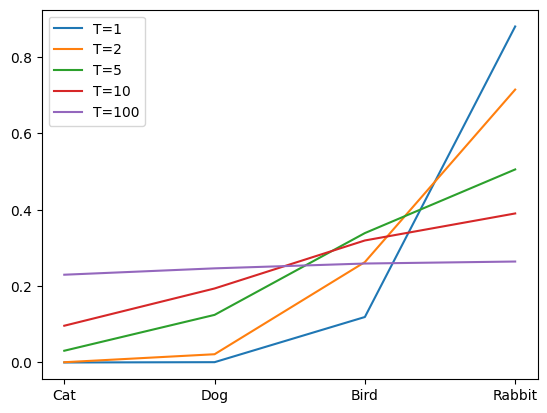

In [21]:
logits = np.array([-5, 2, 7, 9])

T = 1
softmax_1 = np.exp(logits/T) / sum(np.exp(logits/T))
plt.plot(softmax_1, label='T=1')

T = 2
softmax_2 = np.exp(logits/T) / sum(np.exp(logits/T))
plt.plot(softmax_2, label='T=2')

T = 5
softmax_5 = np.exp(logits/T) / sum(np.exp(logits/T))
plt.plot(softmax_5, label='T=5')

T = 10
softmax_10 = np.exp(logits/T) / sum(np.exp(logits/T))
plt.plot(softmax_10, label='T=10')

T = 100
softmax_100 = np.exp(logits/T) / sum(np.exp(logits/T))
plt.plot(softmax_100, label='T=100')

plt.xticks(np.arange(4), ['Cat', 'Dog', 'Bird', 'Rabbit'])
plt.legend()
plt.show


### Define Distillation Framework

In [22]:
class Distiller(nn.Module):
    def __init__(self, teacher, student, type):
        super(Distiller, self).__init__()

        # 1. Finish the __init__ method.
        self.teacher = teacher
        self.student = student

        self.type = type

    def forward(self, x, target):
        # 2. Finish the forward pass.
        with torch.no_grad():
            teacher_features, teacher_logits  = self.teacher(x)

        student_features, student_logits = self.student(x)


        if self.type == 'response':

            with torch.no_grad():
                teacher_out = self.teacher(x)
                if isinstance(teacher_out, tuple):
                    teacher_logits = teacher_out[0]
                else:
                    teacher_logits = teacher_out

            student_out = self.student(x)
            if isinstance(student_out, tuple):
                student_logits = student_out[0]
            else:
                student_logits = student_out

            # call the loss_re()
            loss_distill = loss_re(
                                    student_logits,
                                    teacher_logits,
                                    target
                                )

        elif self.type == 'feature':
            with torch.no_grad():
                teacher_logits, teacher_features = self.teacher(x)

            student_logits, student_features = self.student(x)


            if isinstance(teacher_features, list):
                teacher_features = teacher_features[0]
            if isinstance(student_features, list):
                student_features = student_features[0]

            # call the loss_fe()
            loss_distill = loss_fe(student_logits,student_features,teacher_features,labels = target)

        else:
            raise ValueError(f'Error: only support response-based and feature-based distillation')

        return student_logits, loss_distill

### Training function

In [23]:
def train_distillation(distiller, student, train_loader, val_loader, epochs, learning_rate, device):
    ce_loss = nn.CrossEntropyLoss()
    # define the parameter the optimizer used
    optimizer = torch.optim.Adam(distiller.student.parameters() , lr=learning_rate)


    loss = []
    train_error=[]
    val_error = []
    valdation_error = []
    train_loss = []
    valdation_loss = []
    train_accuraacy = []
    valdation_accuracy= []

    for epoch in range(epochs):
        distiller.train()
        distiller.teacher.train()
        distiller.student.train()

        train_loss = 0.0
        valid_loss = 0.0
        train_acc = 0.0
        valid_acc  = 0.0
        correct = 0.
        total = 0.
        V_correct = 0.
        V_total = 0.
        train_bar = tqdm(train_loader, file=sys.stdout)
        for step, data in enumerate(train_bar):
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            outputs, loss = distiller(images, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            pred = outputs.data.max(1, keepdim=True)[1]
            result = pred.eq(labels.data.view_as(pred))
            result = np.squeeze(result.cpu().numpy())
            correct += np.sum(result)
            total += images.size(0)
            train_bar.desc = "train epoch[{}/{}]".format(epoch + 1, epochs)

        distiller.eval()
        distiller.teacher.eval()
        distiller.student.eval()

        with torch.no_grad():
            val_bar = tqdm(val_loader, file=sys.stdout)
            for val_data in val_bar:

                val_images, val_labels = val_data
                val_images, val_labels = val_images.to(device), val_labels.to(device)

                outputs, loss = distiller(val_images, val_labels)

                valid_loss += loss.item() * val_images.size(0)
                pred = outputs.max(1, keepdim=True)[1]
                V_correct += np.sum(np.squeeze(pred.eq(val_labels.data.view_as(pred))).cpu().numpy())
                V_total += val_images.size(0)
                val_bar.desc = "valid epoch[{}/{}]".format(epoch + 1, epochs)

        train_loss = train_loss / len(train_loader.dataset)
        train_error.append(train_loss)
        valid_loss = valid_loss / len(val_loader.dataset)
        val_error.append(valid_loss)
        train_accuraacy.append( correct / total)
        valdation_accuracy.append(V_correct / V_total)

        print('\tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(train_loss, valid_loss))
        print('\tTrain Accuracy: %.3fd%% (%2d/%2d)\tValdation Accuracy: %.3fd%% (%2d/%2d) '% (100. * correct / total, correct, total, 100. * V_correct / V_total, V_correct, V_total))

    print('Finished Distilling')

## Response-based distillation

In [24]:
# Decide the epochs and learning rate
Student_re = resnet18(num_classes=10)
Student_re = Student_re.to(device)
distiller_re = Distiller(Teacher, Student_re, type='response')
train_distillation(distiller_re, Student_re, train_loader, val_loader, epochs=30 , learning_rate=0.001 , device=device)

valid epoch[1/30]: 100%|██████████| 79/79 [00:10<00:00,  7.32it/s]
	Training Loss: 7.768477 	Validation Loss: 5.263927
	Train Accuracy: 50.447d% (20179/40000)	Valdation Accuracy: 59.140d% (5914/10000) 
valid epoch[2/30]: 100%|██████████| 79/79 [00:10<00:00,  7.44it/s]
	Training Loss: 3.896192 	Validation Loss: 2.684877
	Train Accuracy: 65.778d% (26311/40000)	Valdation Accuracy: 70.670d% (7067/10000) 
valid epoch[3/30]: 100%|██████████| 79/79 [00:10<00:00,  7.33it/s]
	Training Loss: 2.244610 	Validation Loss: 2.165039
	Train Accuracy: 73.125d% (29250/40000)	Valdation Accuracy: 70.630d% (7063/10000) 
valid epoch[4/30]: 100%|██████████| 79/79 [00:10<00:00,  7.40it/s]
	Training Loss: 1.478505 	Validation Loss: 1.247482
	Train Accuracy: 77.123d% (30849/40000)	Valdation Accuracy: 77.510d% (7751/10000) 
valid epoch[5/30]: 100%|██████████| 79/79 [00:10<00:00,  7.40it/s]
	Training Loss: 1.119063 	Validation Loss: 1.000797
	Train Accuracy: 79.108d% (31643/40000)	Valdation Accuracy: 78.120d% (781

In [25]:
reS_loss, reS_accuracy = test(distiller_re, test_loader, type='distiller', device=device)

test: 100%|██████████| 79/79 [00:09<00:00,  8.34it/s]
test_loss: 0.407  test_accuracy: 87.590


## Feature-based distillation

In [26]:
# Decide the epochs and learning rate
Student_fe = resnet18(num_classes=10)
Student_fe = Student_fe.to(device)
distiller_fe = Distiller(Teacher, Student_fe, type='feature')
train_distillation(distiller_fe, Student_fe, train_loader, val_loader, epochs= 40, learning_rate= 0.001, device=device)

valid epoch[1/40]: 100%|██████████| 79/79 [00:10<00:00,  7.36it/s]
	Training Loss: 1.719744 	Validation Loss: 1.242701
	Train Accuracy: 48.093d% (19237/40000)	Valdation Accuracy: 57.980d% (5798/10000) 
valid epoch[2/40]: 100%|██████████| 79/79 [00:10<00:00,  7.36it/s]
	Training Loss: 0.966854 	Validation Loss: 0.838456
	Train Accuracy: 65.770d% (26308/40000)	Valdation Accuracy: 68.610d% (6861/10000) 
valid epoch[3/40]: 100%|██████████| 79/79 [00:10<00:00,  7.46it/s]
	Training Loss: 0.735021 	Validation Loss: 0.716052
	Train Accuracy: 72.745d% (29098/40000)	Valdation Accuracy: 72.410d% (7241/10000) 
valid epoch[4/40]: 100%|██████████| 79/79 [00:10<00:00,  7.33it/s]
	Training Loss: 0.618828 	Validation Loss: 0.645468
	Train Accuracy: 76.688d% (30675/40000)	Valdation Accuracy: 74.020d% (7402/10000) 
valid epoch[5/40]: 100%|██████████| 79/79 [00:10<00:00,  7.41it/s]
	Training Loss: 0.551143 	Validation Loss: 0.548022
	Train Accuracy: 79.315d% (31726/40000)	Valdation Accuracy: 78.290d% (782

In [27]:
ftS_loss, ftS_accuracy = test(distiller_fe, test_loader, type='distiller', device=device)

test: 100%|██████████| 79/79 [00:09<00:00,  8.60it/s]
test_loss: 0.376  test_accuracy: 87.390


## Result and Comparison

In [28]:
print(f'Teacher from scratch: loss = {T_loss:.2f}, accuracy = {T_accuracy:.2f}')
print(f'Student from scratch: loss = {S_loss:.2f}, accuracy = {S_accuracy:.2f}')
print(f'Response-based student: loss = {reS_loss:.2f}, accuracy = {reS_accuracy:.2f}')
print(f'Featured-based student: loss = {ftS_loss:.2f}, accuracy = {ftS_accuracy:.2f}')

Teacher from scratch: loss = 0.44, accuracy = 87.91
Student from scratch: loss = 0.56, accuracy = 81.57
Response-based student: loss = 0.41, accuracy = 87.59
Featured-based student: loss = 0.38, accuracy = 87.39
